# PyPSA Übung 1

### a. Dynamischer Stromtarif mit Heimspeicher

Da seit 2025 dynamische Stromtarife verpflichtend angeboten werden müssen, überlegen Sie ihren Tarif zu einen solchen zu wechseln. Um Ihren Verbrauch zu flexibilisieren wollen Sie sich einen Lithium-Ionen-Heimspeicher zulegen. Ihnen liegen die Strompreise für 2024 stündlich aufgeschlüsselt, sowie der Stromverbrauch ihres Eigenheims vor. Bestimmen Sie die ökonomisch optimale Größe des Heimspeichers.

Die Kosten für den Heimspeicher können mit 750 €/kWh angenommen werden. Die Lebenszeit beträgt 20 Jahre, der Zinssatz kann mit 2% angenommen werden. Die _round trip_ Effizienz beträgt 95%. Standverluste können vernachlässigt werden.

Modellskizze:


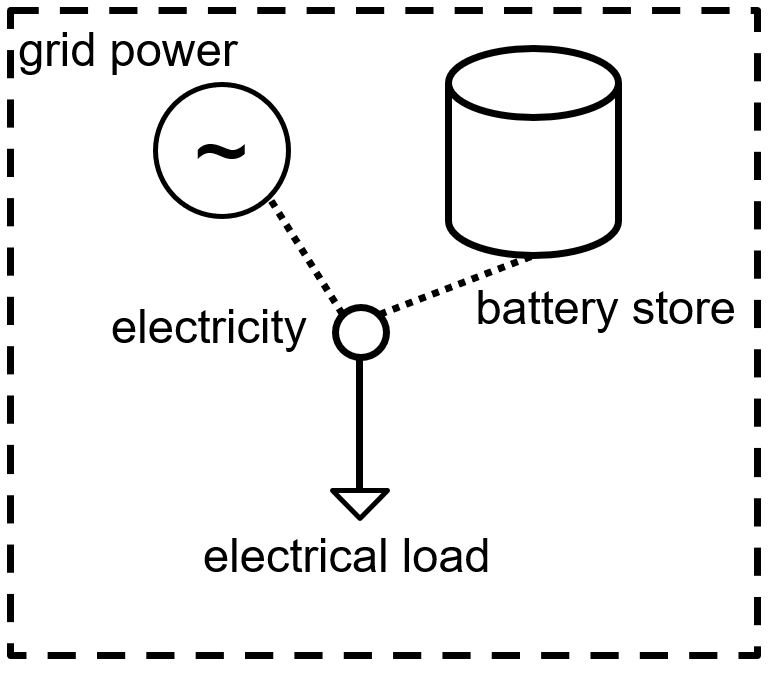

Importieren Sie zunächst die notwendigen Bibliotheken

In [2]:
import pypsa
import pandas as pd
import numpy as np

Lesen Sie die Strompreise sowie Netzlast ein ('PyPSA_1.csv')

In [3]:
df_data = pd.read_csv('data_PyPSA_1.csv')
strompreis = df_data['Strompreis [Euro/kWh]']
last =  df_data['Netzlast [kW]']


Berechnen Sie die Stromkosten ohne Heimspeicher

In [4]:
ref_kosten = sum(last * strompreis)
print(ref_kosten)

1243.503089993538


Definieren Sie die restlichen Parameter

In [5]:
zinssatz = 0.02 # Zinsen in pu
lebensdauer_batterie = 20 # Jahre
roundtrip_eff_batterie = 0.95 # Wikrungsgrad in pu
invest_kosten_batterie = 750 #in Euro 
annuitaet_batterie = invest_kosten_batterie*((1+zinssatz)**lebensdauer_batterie)*zinssatz/((1+zinssatz)**lebensdauer_batterie-1)

Bauen Sie ein PyPSA Netzwerk auf, welches die Problemstellung darstellt.

In [6]:
last.max()

2.070127855

In [7]:
#PyPSA Netzwerk 
network = pypsa.Network()
network.set_snapshots(range(0,8784)) #Schaltjahr beachten

#Bus
network.add('Bus', name = 'electricity')

#Load
network.add('Load', name = 'elctrical_load', bus = 'electricity', p_set = last)

#Generator
network.add('Generator', name = 'grid_power', bus = 'electricity', p_nom = np.inf, marginal_cost = strompreis)

#Storage
network.add('StorageUnit', name = 'battery', bus = 'electricity', p_nom_extendable = True, 
            capital_cost = annuitaet_batterie, max_hours = 1, efficiency_store = roundtrip_eff_batterie**0.5,
            efficiency_dispatch = roundtrip_eff_batterie**0.5)

Erstellen Sie das Linopy Modell des PyPSA Netzwerks schon vor der Optimierung und lassen Sie sich dieses ausgeben. Verwenden Sie dabei:
```python
network.optimize.create_model()
print(network.model)
```
Dadurch werden Gemeinsamkeiten und Unterschiede zwischen dem von PyPSA erstelltem Modell und dem Linopy Modell aus Linopy Übung 02 sichtbar.

In [8]:
network.optimize.create_model()
print(network.model)

Index(['electricity'], dtype='str', name='name')


C:\Users\PC\AppData\Local\Temp\ipykernel_4624\2870517612.py:1: FutureWarning: The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.
  network.optimize.create_model()


TypeError: Passing a Dataset as `data_vars` to the Dataset constructor is not supported. Use `ds.copy()` to create a copy of a Dataset.

Lösen Sie das Modell

In [ ]:
network.optimize(solver_name = 'gurobi')

/tmp/ipykernel_17255/4088711822.py:1: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['electricity'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - log_to_console: True
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 229.70it/s]
INFO:linopy.io: Writing time: 0.23s


Set parameter ServerTimeout to value 10


INFO:gurobipy:Set parameter ServerTimeout to value 10


Set parameter TokenServer to value "139.6.183.241"


INFO:gurobipy:Set parameter TokenServer to value "139.6.183.241"


...

Solved in 13935 iterations and 4.25 seconds (0.51 work units)


INFO:gurobipy:Solved in 13935 iterations and 4.25 seconds (0.51 work units)


Optimal objective  1.240123687e+03


INFO:gurobipy:Optimal objective  1.240123687e+03
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 35137 primals, 79057 duals
Objective: 1.24e+03
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

Geben Sie sich die größe des Batteriespeichers, dessen Gesamtkosten und die Gesamtkosten (Zielfunktion) aus

In [ ]:
print('Batterie-Kapazität',round(network.storage_units.p_nom_opt["battery"],2),"kWh" )
batteriekosten = network.storage_units.p_nom_opt["battery"] * annuitaet_batterie * lebensdauer_batterie
print('Batteriespeicher-Gesamtkosten:', round(batteriekosten,2), "€")
print('Jährliche Kosten', round(network.objective, 2), '€')

Batterie-Kapazität 0.59 kWh
Batteriespeicher-Gesamtkosten: 543.96 €
Jährliche Kosten 1240.12 €


In [ ]:
network.statistics()

,,Optimal Capacity,Installed Capacity,Supply,Withdrawal,Energy Balance,Transmission,Capacity Factor,Curtailment,Capital Expenditure,Operational Expenditure,Revenue,Market Value
Generator,-,inf,inf,4033.08026,0.00000,4033.08026,0.0,0.000000,inf,0.00000,1212.92556,1212.92556,0.300736
Load,-,0.00000,0.0,0.00000,4014.08598,-4014.08598,0.0,NaN,0.00000,0.00000,0.00000,-1240.12369,NaN
StorageUnit,-,0.59297,0.0,360.89142,379.88571,-18.99429,0.0,0.142216,5227.65205,27.19812,0.00000,27.19812,0.075444


### b. Dynamischer Stromtarif mit Heimspeicher und PV-Anlage

Nun soll ein zweites Szenario untersucht werden, in dem auf dem Dach des Eigenheims eine bestehende PV-Anlage mit einer Nennleistung von 5 kW installiert ist. Die Einspeisevergütung der Anlage liegt bei 8 ct/kWh. Die Kosten für den Heimspeicher bleiben gleich. 

Modellskizze:

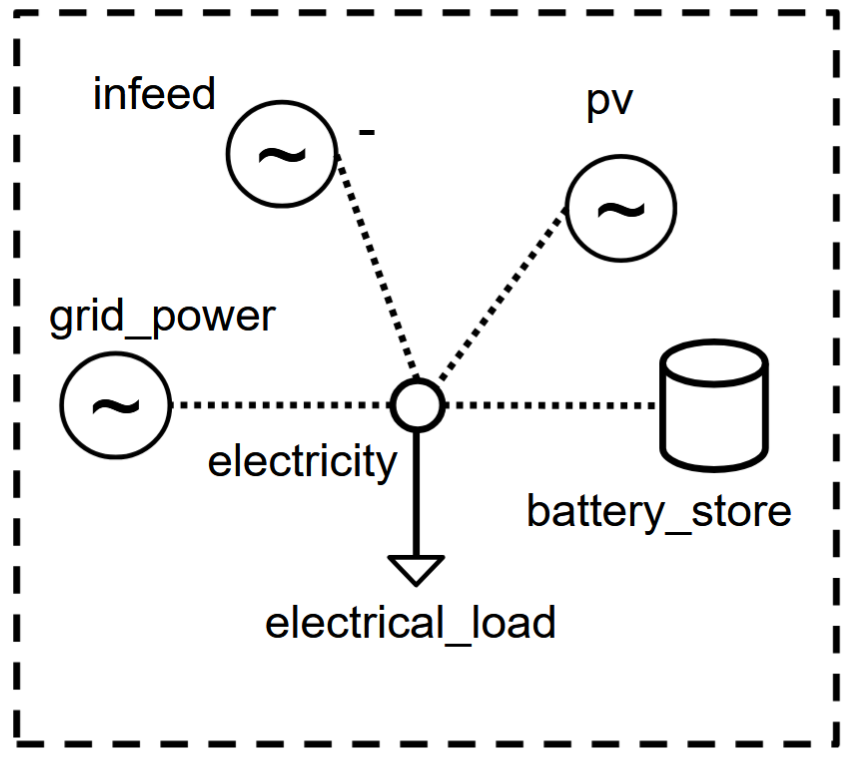

Ergänzen Sie die neuen Parameter. Lesen Sie dazu auch die PV-Erzeugung aus der csv-Datei als Pandas-Dataframe ein.

In [ ]:
p_pv_nom = 5 #kW
einspeiseverguetung = 0.08 #€/kW
pv_erzeugung = df_data["PV Erzeugung [kW]"]
print((pv_erzeugung/p_pv_nom).head(50))

0     0.000
1     0.000
2     0.000
3     0.000
4     0.000
5     0.000
6     0.000
7     0.000
8     0.001
9     0.006
10    0.010
11    0.007
12    0.011
13    0.020
14    0.018
15    0.000
16    0.000
17    0.000
18    0.000
19    0.000
20    0.000
21    0.000
22    0.000
23    0.000
24    0.000
25    0.000
26    0.000
27    0.000
28    0.000
29    0.000
30    0.000
31    0.000
32    0.092
33    0.195
34    0.343
35    0.415
36    0.335
37    0.264
38    0.141
39    0.003
40    0.000
41    0.000
42    0.000
43    0.000
44    0.000
45    0.000
46    0.000
47    0.000
48    0.000
49    0.000
Name: PV Erzeugung [kW], dtype: float64


Erstellen Sie ein neues Netzwerk mit den zusätzlichen Komponenten. 

In [ ]:
#PyPSA Netzwerk 
network_pv = pypsa.Network()
network_pv.set_snapshots(range(0,8784)) #Schaltjahr beachten

#Bus
network_pv.add('Bus', name = 'electricity')

#Load
network_pv.add('Load', name = 'elctrical_load', bus = 'electricity', p_set = last)

#Generator
network_pv.add('Generator', name = 'grid_power', bus = 'electricity', p_nom = np.inf, marginal_cost = strompreis)
network_pv.add('Generator', name = 'pv', bus = 'electricity', p_nom = p_pv_nom, p_min_pu=0, p_max_pu=pv_erzeugung/p_pv_nom)
network_pv.add('Generator', name = 'infeed', bus = 'electricity', p_nom = p_pv_nom, min_pu=0, p_max_pu=pv_erzeugung/p_pv_nom, sign=-1 , marginal_cost=-einspeiseverguetung)

#Storage
network_pv.add('StorageUnit', name = 'battery', bus = 'electricity', p_nom_extendable = True, 
            capital_cost = annuitaet_batterie, max_hours = 1, efficiency_store = roundtrip_eff_batterie**0.5,
            efficiency_dispatch = roundtrip_eff_batterie**0.5)

Lösen Sie das neue Modell.

In [ ]:
network_pv.optimize(solver_name="gurobi")

/tmp/ipykernel_17255/4231966340.py:1: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.

Index(['electricity'], dtype='str', name='name')
INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - log_to_console: True
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 142.81it/s]
INFO:linopy.io: Writing time: 0.28s


Set parameter ServerTimeout to value 10


INFO:gurobipy:Set parameter ServerTimeout to value 10


Set parameter TokenServer to value "139.6.183.241"


INFO:gurobipy:Set parameter TokenServer to value "139.6.183.241"


...

Solved in 14212 iterations and 2.22 seconds (0.80 work units)


INFO:gurobipy:Solved in 14212 iterations and 2.22 seconds (0.80 work units)


Optimal objective  1.239864579e+03


INFO:gurobipy:Optimal objective  1.239864579e+03
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 52705 primals, 114193 duals
Objective: 1.24e+03
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance were not assigned to the network.


('ok', 'optimal')

Geben Sie sich die neuen Werte der Größe des Batteriespeichers, der Batteriekosten und der jährlichen Gesamtkosten (Zielfunktion) aus.

In [ ]:
print('Batterie-Kapazität',round(network_pv.storage_units.p_nom_opt["battery"],2),"kWh" )
batteriekosten = network_pv.storage_units.p_nom_opt["battery"] * annuitaet_batterie * lebensdauer_batterie
print('Batteriespeicher-Gesamtkosten:', round(batteriekosten,2), "€")
print('Jährliche Kosten', round(network_pv.objective, 2), '€')


Batterie-Kapazität 4.17 kWh
Batteriespeicher-Gesamtkosten: 3826.34 €
Jährliche Kosten 315.47 €
